C:\Users\kanda\AppData\Local\Temp\ipykernel_45664\2131705093.py:21: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  auditory_mask_res = image.resample_to_img(auditory_mask, fmri_data, interpolation='nearest')
C:\Users\kanda\AppData\Local\Temp\ipykernel_45664\2131705093.py:21: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  auditory_mask_res = image.resample_to_img(auditory_mask, fmri_data, interpolation='nearest')
C:\Users\kanda\AppData\Local\Temp\ipykernel_45664\2131705093.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  motivation_mask_res = image.resample_to_img(motivation_mask, fmri_data,

Correlation between auditory and motivation regions: 0.626
P-value: 0.0000


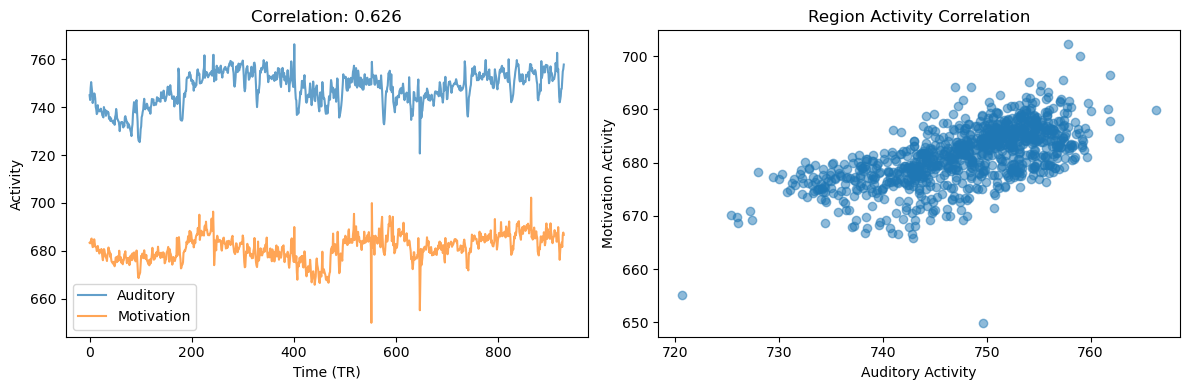

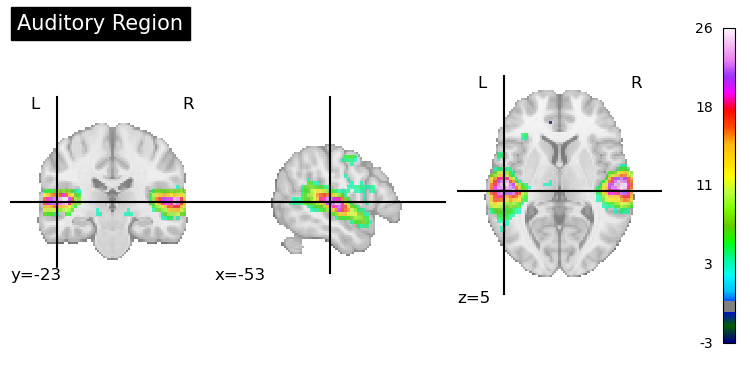

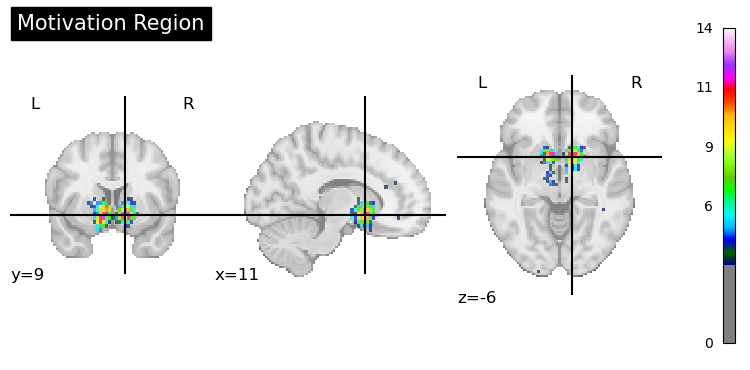

In [2]:
import nibabel as nib
import numpy as np
from nilearn import image, plotting
from nilearn.maskers import NiftiMasker
import glob
import pandas as pd
from scipy.stats import pearsonr

import matplotlib.pyplot as plt

# Load the neurosynth mask files
auditory_mask = nib.load('auditory_association-test_z_FDR_0.01.nii.gz')
motivation_mask = nib.load('motivation_association-test_z_FDR_0.01.nii.gz')

# Load the specific fMRI BOLD file
fmri_data = nib.load('sub-01_task-classicalMusic_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz')
fmri_array = fmri_data.get_fdata()

# Resample masks to the fMRI image space so shapes/affines match
# Use nearest interpolation for masks to preserve discrete labels
auditory_mask_res = image.resample_to_img(auditory_mask, fmri_data, interpolation='nearest')
motivation_mask_res = image.resample_to_img(motivation_mask, fmri_data, interpolation='nearest')

# Create binary masks from resampled neurosynth data (threshold at 0)
auditory_array = auditory_mask_res.get_fdata() > 0
motivation_array = motivation_mask_res.get_fdata() > 0

# Sanity checks to avoid indexing errors
if auditory_array.shape != fmri_array.shape[:3]:
	raise ValueError(f"Auditory mask shape {auditory_array.shape} does not match fMRI spatial shape {fmri_array.shape[:3]}")
if motivation_array.shape != fmri_array.shape[:3]:
	raise ValueError(f"Motivation mask shape {motivation_array.shape} does not match fMRI spatial shape {fmri_array.shape[:3]}")

if auditory_array.sum() == 0:
	raise ValueError("Auditory mask has no voxels overlapping with the fMRI image after resampling.")
if motivation_array.sum() == 0:
	raise ValueError("Motivation mask has no voxels overlapping with the fMRI image after resampling.")

# Extract time series from both regions
# fmri_array has shape (X, Y, Z, T); boolean indexing with a (X, Y, Z) mask returns (n_voxels, T)
auditory_voxels = fmri_array[auditory_array]  # shape (n_auditory_voxels, T)
motivation_voxels = fmri_array[motivation_array]  # shape (n_motivation_voxels, T)

# Compute mean time series across voxels
auditory_ts = auditory_voxels.mean(axis=0)
motivation_ts = motivation_voxels.mean(axis=0)

# Calculate correlation (ensure time series lengths match)
if auditory_ts.shape[0] != motivation_ts.shape[0]:
	raise ValueError("Time series lengths do not match between regions.")

correlation, p_value = pearsonr(auditory_ts, motivation_ts)

print(f"Correlation between auditory and motivation regions: {correlation:.3f}")
print(f"P-value: {p_value:.4f}")

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot time series
axes[0].plot(auditory_ts, label='Auditory', alpha=0.7)
axes[0].plot(motivation_ts, label='Motivation', alpha=0.7)
axes[0].set_xlabel('Time (TR)')
axes[0].set_ylabel('Activity')
axes[0].legend()
axes[0].set_title(f'Correlation: {correlation:.3f}')

# Plot scatter
axes[1].scatter(auditory_ts, motivation_ts, alpha=0.5)
axes[1].set_xlabel('Auditory Activity')
axes[1].set_ylabel('Motivation Activity')
axes[1].set_title('Region Activity Correlation')

plt.tight_layout()
plt.show()

# Brain image visualization (use resampled masks so they overlay correctly)
plotting.plot_roi(auditory_mask_res, title='Auditory Region')
plotting.plot_roi(motivation_mask_res, title='Motivation Region')



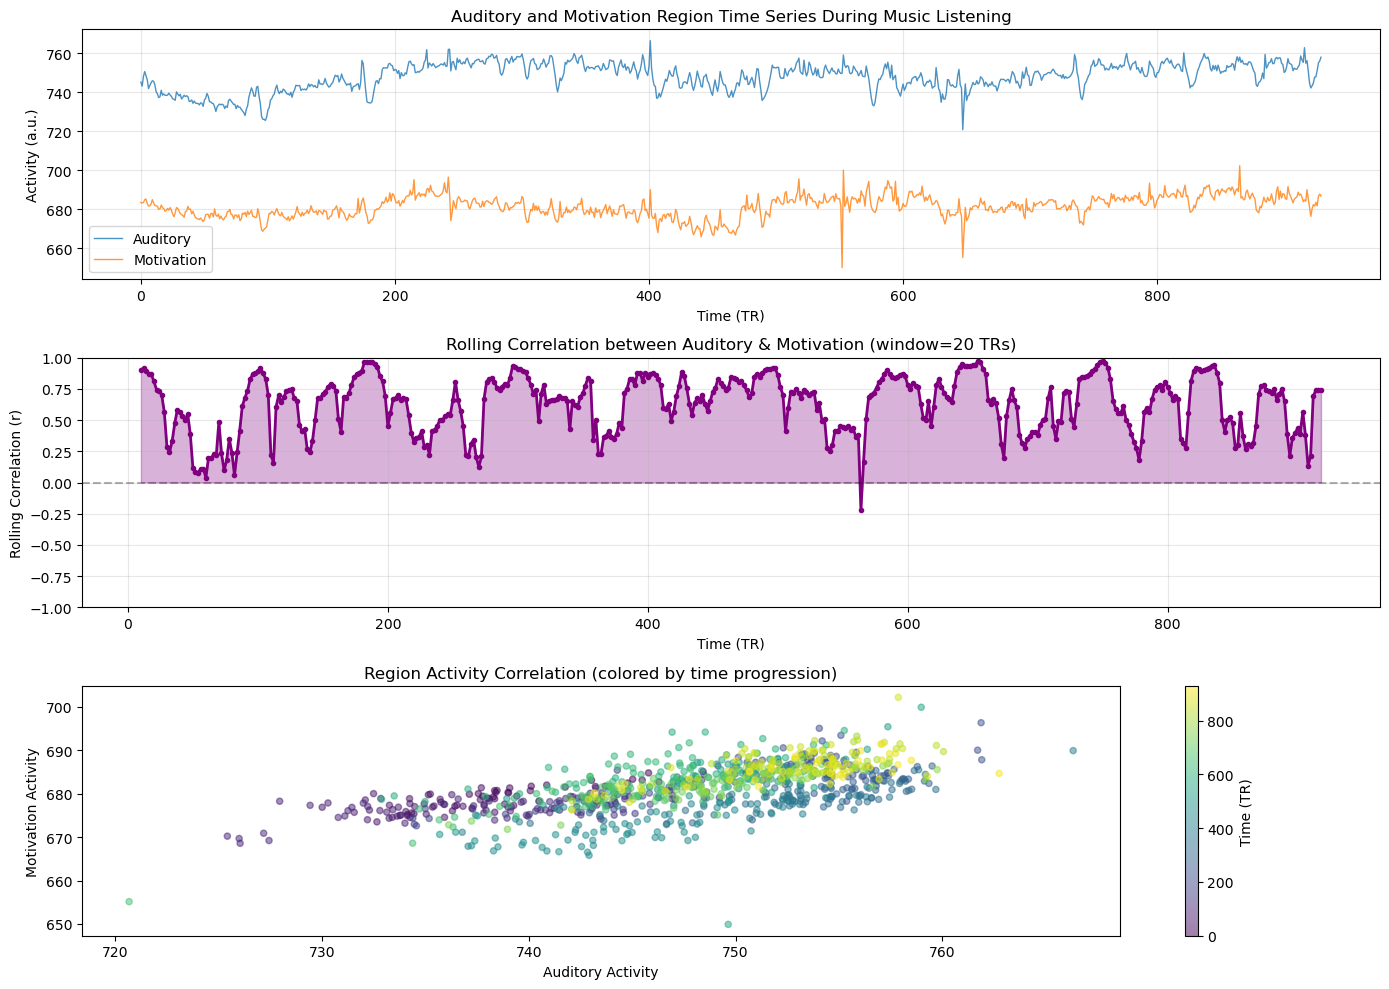


Rolling Correlation Summary:
  Mean correlation: 0.627
  Min correlation: -0.219
  Max correlation: 0.975
  Std deviation: 0.226

Figure saved as 'rolling_correlation_timeseries.png'


In [3]:

# Rolling-window correlation between auditory and motivation regions over time
# This shows how the correlation between the two regions changes as the music plays

import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# Define rolling window size (e.g., 20 TRs ≈ 40 seconds at TR=2s)
window_size = 20
step_size = 2  # step by 2 TRs for smoother visualization

# Compute rolling correlation
rolling_corr = []
window_times = []

for i in range(0, len(auditory_ts) - window_size, step_size):
    auditory_window = auditory_ts[i:i+window_size]
    motivation_window = motivation_ts[i:i+window_size]
    
    # Compute Pearson correlation for this window
    if len(auditory_window) == window_size and len(motivation_window) == window_size:
        corr, _ = pearsonr(auditory_window, motivation_window)
        rolling_corr.append(corr)
        # Time is in TRs (assuming TR=2s, convert to seconds)
        window_times.append((i + window_size/2) * 2.0)

rolling_corr = np.array(rolling_corr)
window_times = np.array(window_times)

# Create visualization with three subplots
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: Time series of both regions
axes[0].plot(auditory_ts, label='Auditory', alpha=0.8, linewidth=1)
axes[0].plot(motivation_ts, label='Motivation', alpha=0.8, linewidth=1)
axes[0].set_xlabel('Time (TR)')
axes[0].set_ylabel('Activity (a.u.)')
axes[0].set_title('Auditory and Motivation Region Time Series During Music Listening')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Rolling correlation over time
axes[1].plot(window_times / 2.0, rolling_corr, linewidth=2, color='purple', marker='o', markersize=3)
axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1].fill_between(window_times / 2.0, rolling_corr, alpha=0.3, color='purple')
axes[1].set_xlabel('Time (TR)')
axes[1].set_ylabel('Rolling Correlation (r)')
axes[1].set_title(f'Rolling Correlation between Auditory & Motivation (window={window_size} TRs)')
axes[1].grid(alpha=0.3)
axes[1].set_ylim([-1, 1])

# Plot 3: Scatter plot of region activities (colored by time)
scatter = axes[2].scatter(auditory_ts, motivation_ts, c=range(len(auditory_ts)), 
                          cmap='viridis', alpha=0.5, s=20)
axes[2].set_xlabel('Auditory Activity')
axes[2].set_ylabel('Motivation Activity')
axes[2].set_title('Region Activity Correlation (colored by time progression)')
cbar = plt.colorbar(scatter, ax=axes[2])
cbar.set_label('Time (TR)')

plt.tight_layout()
plt.savefig('rolling_correlation_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"\nRolling Correlation Summary:")
print(f"  Mean correlation: {rolling_corr.mean():.3f}")
print(f"  Min correlation: {rolling_corr.min():.3f}")
print(f"  Max correlation: {rolling_corr.max():.3f}")
print(f"  Std deviation: {rolling_corr.std():.3f}")
print(f"\nFigure saved as 'rolling_correlation_timeseries.png'")
